In [2]:
from vllm import LLM, SamplingParams
modelp="/volume/ailab4sci/txie/ydl/short_ablation2/ShortRL-logic1e-6-200-1/actor/global_step_1686"

llm = LLM(model=modelp)




/volume/ailab4sci/miniconda/envs/shortrl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-24 16:24:02,289	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
/volume/ailab4sci/miniconda/envs/shortrl/lib/python3.10/site-packages/vllm/connections.py:8: RuntimeWarning: Failed to read commit hash:
No module named 'vllm._version'
  from vllm.version import __version__ as VLLM_VERSION


INFO 04-24 16:24:02 config.py:1670] Downcasting torch.float32 to torch.float16.
WARNING 04-24 16:24:06 arg_utils.py:953] Chunked prefill is enabled by default for models with max_model_len > 32K. Currently, chunked prefill might not work with some features or models. If you encounter any issues, please disable chunked prefill by setting --enable-chunked-prefill=False.
INFO 04-24 16:24:06 config.py:1005] Chunked prefill is enabled with max_num_batched_tokens=512.
INFO 04-24 16:24:06 llm_engine.py:237] Initializing an LLM engine (vdev) with config: model='/volume/ailab4sci/txie/ydl/short_ablation2/ShortRL-logic1e-6-200-1/actor/global_step_1686', speculative_config=None, tokenizer='/volume/ailab4sci/txie/ydl/short_ablation2/ShortRL-logic1e-6-200-1/actor/global_step_1686', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, rope_scaling=None, rope_theta=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=131072, d

Loading safetensors checkpoint shards:   0% Completed | 0/7 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  14% Completed | 1/7 [00:02<00:14,  2.43s/it]
Loading safetensors checkpoint shards:  29% Completed | 2/7 [00:05<00:13,  2.79s/it]
Loading safetensors checkpoint shards:  43% Completed | 3/7 [00:08<00:11,  2.88s/it]
Loading safetensors checkpoint shards:  57% Completed | 4/7 [00:11<00:08,  2.95s/it]
Loading safetensors checkpoint shards:  71% Completed | 5/7 [00:13<00:05,  2.65s/it]
Loading safetensors checkpoint shards:  86% Completed | 6/7 [00:16<00:02,  2.70s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:17<00:00,  2.14s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:17<00:00,  2.49s/it]



INFO 04-24 16:24:28 model_runner.py:1071] Loading model weights took 14.2716 GB
INFO 04-24 16:24:29 gpu_executor.py:122] # GPU blocks: 64632, # CPU blocks: 4681
INFO 04-24 16:24:29 gpu_executor.py:126] Maximum concurrency for 131072 tokens per request: 7.89x
INFO 04-24 16:24:31 model_runner.py:1402] Capturing the model for CUDA graphs. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
INFO 04-24 16:24:31 model_runner.py:1406] CUDA graphs can take additional 1~3 GiB memory per GPU. If you are running out of memory, consider decreasing `gpu_memory_utilization` or enforcing eager mode. You can also reduce the `max_num_seqs` as needed to decrease memory usage.
INFO 04-24 16:24:39 model_runner.py:1530] Graph capturing finished in 8 secs.


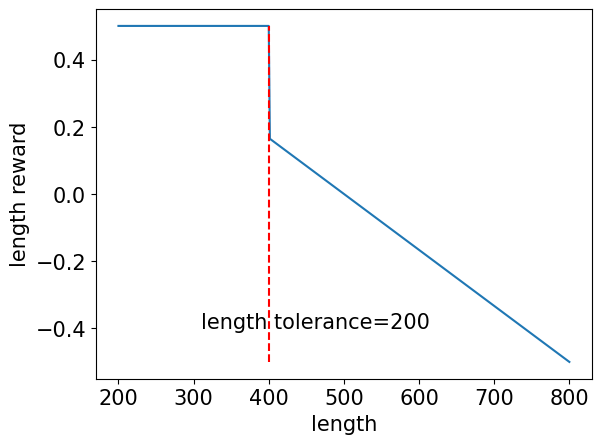

In [23]:
max_len=800
min_len=200
length_tolerance=200
frontsize=15
def f(x,max_len,min_len,length_tolerance):
    
    # if x>min_len+length_tolerance: 
    #     return 0.5-(x-min_len)/(max_len-min_len)
    # else:
    #     return 0.5
    y = np.zeros_like(x)
    y[x > min_len + length_tolerance] = 0.5 - (x[x > min_len + length_tolerance] - min_len) / (max_len - min_len)
    y[x <= min_len + length_tolerance] = 0.5
    return y
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(min_len, max_len, 400)
y=f(x,max_len,min_len,length_tolerance)
plt.plot(x, y)
plt.plot([min_len+length_tolerance,min_len+length_tolerance], [-0.5,0.5], linestyle='--', color='r')
plt.text(min_len+length_tolerance-90,-0.4,'length tolerance={}'.format(length_tolerance),fontsize=frontsize)
# plt.title('length reward', fontsize=frontsize)
plt.xlabel('length',fontsize=frontsize)
plt.ylabel('length reward',fontsize=frontsize)
plt.xticks(fontsize=frontsize)
plt.yticks(fontsize=frontsize)
plt.show()

In [3]:
datap="/volume/ailab4sci/txie/ydl/Short-RL/Logic-RL/data/kk/instruct/3ppl/test.parquet"
#read parquet file
import pandas as pd
data=pd.read_parquet(datap)
prompt=data.iloc[0]['prompt'][0]['content']
sampling_params = SamplingParams(temperature=0.7, n=4,max_tokens=1000)

outputs = llm.generate(prompt, sampling_params)


Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.25s/it, est. speed input: 110.03 toks/s, output: 500.46 toks/s]


In [4]:
for output in outputs:
    prompt = output.prompt
    for i in range(4):
        generated_text = output.outputs[i].text
        print(f"Generated text: {generated_text!r}")

Generated text: ' Let\'s break down these statements to figure out who is a knight and who is a knave on this special island.\n\n1. Amelia: "Evelyn is not a knight."\n2. Penelope: "Penelope is a knight or Evelyn is a knave."\n3. Evelyn: "Penelope is a knight if and only if Penelope is a knave."\n\nLet\'s start with Evelyn\'s statement. It includes a contradiction ("Penelope is a knight if and only if Penelope is a knave.") so we can conclude that Evelyn is a knave.\n\n4. Now let\'s look at Amelia\'s statement: "Evelyn is not a knight." Since Evelyn is a knave, this statement is true, so Amelia is a knight.\n8. Now let\'s look at Penelope\'s statement: "Penelope is a knight or Evelyn is a knave." Since Penelope being a knight satisfies this condition, Penelope is a knight.\n9. Now we know Penelope is a knight.\n10. So, Amelia is a knight\n, Penelope is a knight\n, and Evelyn is a knave.\n (1) Amelia is a knight\n(2) Penelope is a knight\n(3) Evelyn is a knave\n </think><answer>\n (1) Am

: 